In [12]:
from zeus21 import get_T21_coefficients, Power_Spectra, User_Parameters, Cosmo_Parameters_Input, Astro_Parameters, cosmo_wrapper

import matplotlib.pyplot as plt
colors = ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#ee9b00', '#ca6702', '#bb3e03', '#ae2012', '#9b2226']
plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts


In [2]:
# user parameters
UP = User_Parameters(
            precisionboost= 1.0, 
            FLAG_FORCE_LINEAR_CF= 0, 
            MIN_R_NONLINEAR= 0.5, 
            MAX_R_NONLINEAR= 200.0,
            FLAG_DO_DENS_NL= False, 
            FLAG_WF_ITERATIVE= True,
            )

CosmoParams_input_fid = dict(
        omegab= 0.0223828, 
        omegac = 0.1201075, 
        h_fid = 0.67810, 
        As = 2.100549e-09, 
        ns = 0.9660499, 
        tau_fid = 0.05430842, 
        HMF_CHOICE= "ST",
        Flag_emulate_21cmfast = False,
        )

# cosmological parameters
CP, ClassyC, corr, HMFcl = cosmo_wrapper(UP, Cosmo_Parameters_Input(**CosmoParams_input_fid))

In [3]:
def set_astro(quadratic_flag):

    # astrophysical parameters 

    AstroParams_input = dict(

        quadratic_SFRD_lognormal = quadratic_flag, # set quadratic (True) or linear (False)

        # all other astro params
        astromodel = 0,
        accretion_model = 0,
        alphastar = 0.5,
        betastar = -0.5,
        epsstar = 0.1,
        Mc = 3e11,
        Mturn_fixed = None,
        dlog10epsstardz = 0.0,
        fesc10 = 0.1,
        alphaesc = 0.,
        L40_xray = 3.0,
        E0_xray = 500.,
        alpha_xray = -1.0,
        Emax_xray_norm=2000,

        Nalpha_lyA_II = 9690,
        Nalpha_lyA_III = 17900,

        FLAG_MTURN_SHARP= False,

        C0dust = 4.43,
        C1dust = 1.99,
        sigmaUV=0.5,

        USE_POPIII = False,
        alphastar_III = 0, 
        betastar_III = 0,
        fstar_III = 10**(-2.5),
        Mc_III = 1e7,
        dlog10epsstardz_III = 0.0,
        fesc7_III = 10**(-1.35),
        alphaesc_III = -0.3,
        L40_xray_III = 3.0,
        alpha_xray_III = -1.0,        
        USE_LW_FEEDBACK = False,
        A_LW = 2.0,
        beta_LW = 0.6,
        A_vcb = 1.0,
        beta_vcb = 1.8,
        )

    AP = Astro_Parameters(UP, CP, **AstroParams_input)
    
    return AP

In [5]:
AP_quad = set_astro(True)
AP_lin = set_astro(False)

In [7]:
coeff_quad = get_T21_coefficients(UP, CP, ClassyC, AP_quad, HMFcl, zmin=10.)
pk_quad = Power_Spectra(UP, CP, AP_quad, ClassyC, corr, coeff_quad, RSD_MODE=0)

In [8]:
coeff_lin = get_T21_coefficients(UP, CP, ClassyC, AP_lin, HMFcl, zmin=10.)
pk_lin = Power_Spectra(UP, CP, AP_lin, ClassyC, corr, coeff_lin, RSD_MODE=0)

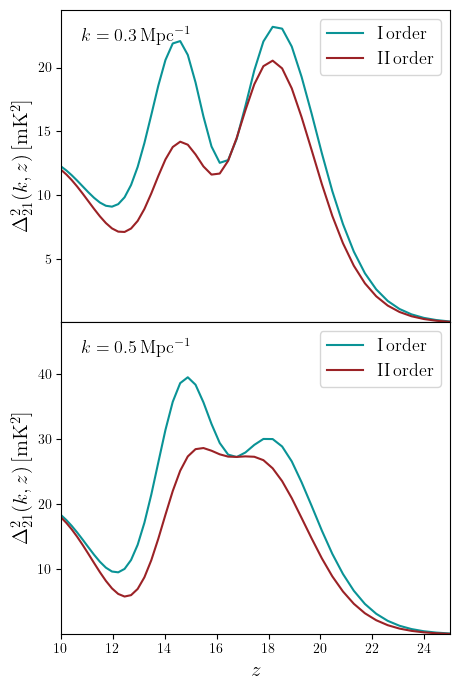

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(4.7, 7), sharex=True, gridspec_kw={'hspace': 0})

id_1 = 35
id_2 = 38
klist = pk_lin.klist_PS # list of k

axes[0].plot(coeff_lin.zintegral,pk_lin.Deltasq_T21[:,id_1], '-', label=r'$\rm I\,order$',color=colors[2])
axes[0].plot(coeff_quad.zintegral,pk_quad.Deltasq_T21[:,id_1], '-', label=r'$\rm II\,order$',color=colors[-1])
axes[0].set_ylabel(r'$\Delta^2_{21}(k,z)\,[{\rm mK^2}]$',fontsize=15)
axes[0].text(0.05, 0.95, r'$k=%g\,{\rm Mpc}^{-1}$'%round(klist[id_1],2), transform=axes[0].transAxes,
             fontsize=13, verticalalignment='top')
axes[0].set_xlim(10,25)
axes[0].set_ylim(1e-1,24.5)
axes[0].legend(loc=1,fontsize=13)

axes[1].plot(coeff_lin.zintegral,pk_lin.Deltasq_T21[:,id_2], '-', label=r'$\rm I\,order$',color=colors[2])
axes[1].plot(coeff_quad.zintegral,pk_quad.Deltasq_T21[:,id_2], '-', label=r'$\rm II\,order$',color=colors[-1])
axes[1].set_ylabel(r'$\Delta^2_{21}(k,z)\,[{\rm mK^2}]$',fontsize=15)
axes[1].text(0.05, 0.95, r'$k=%g\,{\rm Mpc}^{-1}$'%round(klist[id_2],1), transform=axes[1].transAxes,
             fontsize=13, verticalalignment='top')
axes[1].set_ylim(1e-1,48)
axes[1].set_xlim(10,25)
axes[1].legend(fontsize=13,loc=1)
axes[1].set_xlabel(r'$z$',fontsize=15)


plt.tight_layout()